In [ ]:
!pip install -q gdown opencv-python scikit-learn seaborn


In [ ]:
import gdown
import zipfile
import os
import shutil
from pathlib import Path

drive_url = "https://drive.google.com/file/d/1jY9Mh_LvOe_Nl474umz2rFSMzBWOL5ip/view?usp=sharing"

zip_path = "/content/Rice Dataset (1).zip"
extract_path = "/content/Rice_dataset_raw"

gdown.download(drive_url, zip_path, quiet=False, fuzzy=True)

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted.")
print(os.listdir(extract_path))

Downloading...
From (original): https://drive.google.com/uc?id=1jY9Mh_LvOe_Nl474umz2rFSMzBWOL5ip
From (redirected): https://drive.google.com/uc?id=1jY9Mh_LvOe_Nl474umz2rFSMzBWOL5ip&confirm=t&uuid=aa231072-72f4-4476-9b17-72a04d1c4db2
To: /content/Rice Dataset (1).zip
100%|██████████| 2.33G/2.33G [00:44<00:00, 52.1MB/s]


Dataset extracted.
['Rice Dataset']


In [ ]:
from pathlib import Path
import os

raw_path = Path("/content/Rice_dataset_raw")

def find_augmented_part1(path):
    """
    Searches the extracted dataset for the Part-1 'After Augmentation' folder,
    which contains the pre-augmented training images.
    """
    candidates = []
    for folder in path.rglob("*"):
        if folder.is_dir() and "part-1" in folder.name.lower():
            for sub in folder.rglob("*"):
                if sub.is_dir() and "after augmentation" in sub.name.lower():
                    candidates.append(sub)

    if not candidates:
        raise ValueError("Could not find 'Part-1/After Augmentation' folder. Check ZIP structure.")

    return candidates[0]

part1_aug_path = find_augmented_part1(raw_path)

print("Detected Part-1 Augmented dataset root:", part1_aug_path)
print("\nClasses and image counts:")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
total_images = 0

for class_folder in sorted(os.listdir(part1_aug_path)):
    class_path = part1_aug_path / class_folder
    if class_path.is_dir():
        count = sum(
            1 for f in class_path.iterdir()
            if f.is_file() and f.suffix.lower() in image_extensions
        )
        total_images += count
        print(f"- {class_folder}: {count} images")

print(f"\nTotal Part-1 augmented images: {total_images}")

Detected Part-1 Augmented dataset root: /content/Rice_dataset_raw/Rice Dataset/Augmented Dataset/Part-1/After Augmentation

Classes and image counts:
- Healthy: 3000 images
- Insect: 2084 images
- Leaf scald: 1759 images
- Rice Blast: 2138 images
- Rice Leaffolder: 1658 images
- Rice Stripes: 1818 images
- Rice Tungro: 1784 images
- rice: 128 images

Total Part-1 augmented images: 14369


In [ ]:
import os
sample_files = os.listdir(part1_aug_path / 'rice')[:5]
print(sample_files)

['Augmented_0_7665.jpeg', 'Augmented_0_1568.jpeg', 'Augmented_0_2333.jpeg', 'Augmented_0_5890.jpeg', 'Augmented_0_8061.jpeg']


In [ ]:
from sklearn.model_selection import train_test_split
import random, shutil, os

base_dir = '/content/split_dataset_part1'
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(base_dir, split), exist_ok=True)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
classes = sorted(os.listdir(part1_aug_path))

print("Splitting Part-1 Augmented Dataset (70/15/15)\n")

for cls in classes:
    cls_path = part1_aug_path / cls
    if not cls_path.is_dir():
        continue

    images = [f.name for f in cls_path.iterdir()
              if f.is_file() and f.suffix.lower() in image_extensions]

    random.seed(42)
    random.shuffle(images)

    # 70% train, then split remaining 30% into 15% val / 15% test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)

    for split, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        split_cls_dir = os.path.join(base_dir, split, cls)
        os.makedirs(split_cls_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(cls_path / img, os.path.join(split_cls_dir, img))

    total = len(images)
    print(f"{cls}: total={total} | train={len(train_imgs)} ({len(train_imgs)/total:.0%}) | "
          f"val={len(val_imgs)} ({len(val_imgs)/total:.0%}) | "
          f"test={len(test_imgs)} ({len(test_imgs)/total:.0%})")

Splitting Part-1 Augmented Dataset (70/15/15)

Healthy: total=3000 | train=2100 (70%) | val=450 (15%) | test=450 (15%)
Insect: total=2084 | train=1458 (70%) | val=313 (15%) | test=313 (15%)
Leaf scald: total=1759 | train=1231 (70%) | val=264 (15%) | test=264 (15%)
Rice Blast: total=2138 | train=1496 (70%) | val=321 (15%) | test=321 (15%)
Rice Leaffolder: total=1658 | train=1160 (70%) | val=249 (15%) | test=249 (15%)
Rice Stripes: total=1818 | train=1272 (70%) | val=273 (15%) | test=273 (15%)
Rice Tungro: total=1784 | train=1248 (70%) | val=268 (15%) | test=268 (15%)
rice: total=128 | train=89 (70%) | val=19 (15%) | test=20 (16%)


In [ ]:
print("\nFinal split summary:")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_dir, split)
    total = sum(len(os.listdir(os.path.join(split_path, c))) for c in os.listdir(split_path))
    print(f"{split}: {total} images")


Final split summary:
train: 10054 images
val: 2157 images
test: 2158 images


In [ ]:
base_dir = '/content/split_dataset_part1'

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32
base_dir = '/content/split_dataset_part1'

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 10054 files belonging to 8 classes.
Found 2157 files belonging to 8 classes.
Found 2158 files belonging to 8 classes.
Classes: ['Healthy', 'Insect', 'Leaf scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro', 'rice']


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def prep_train(image, label):
    image = data_augmentation(image)
    image = preprocess_input(image)
    return image, label

def prep_eval(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(prep_train, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(prep_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [ ]:
import numpy as np
from sklearn.utils import class_weight

train_labels = []
for _, labels in train_ds.unbatch():
    train_labels.append(np.argmax(labels.numpy()))

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(0.598452380952381), 1: np.float64(0.8619684499314129), 2: np.float64(1.0209179528838344), 3: np.float64(0.8400735294117647), 4: np.float64(1.0834051724137932), 5: np.float64(0.9880110062893082), 6: np.float64(1.0070112179487178), 7: np.float64(14.120786516853933)}


In [ ]:
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,120 (9.90 MB)

 Trainable params: 333,064 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('/content/drive/MyDrive/best_phase1.keras', monitor='val_accuracy', save_best_only=True)
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_phase1,
    class_weight=class_weights_dict
)

Epoch 1/25
315/315 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.4260 - loss: 1.8559 - val_accuracy: 0.5633 - val_loss: 1.4417 - learning_rate: 0.0010
Epoch 2/25
315/315 ━━━━━━━━━━━━━━━━━━━━ 304s 966ms/step - accuracy: 0.5362 - loss: 1.4516 - val_accuracy: 0.5726 - val_loss: 1.4025 - learning_rate: 0.0010
Epoch 3/25
315/315 ━━━━━━━━━━━━━━━━━━━━ 303s 963ms/step - accuracy: 0.5813 - loss: 1.3521 - val_accuracy: 0.5902 - val_loss: 1.3706 - learning_rate: 0.0010
Epoch 4/25
315/315 ━━━━━━━━━━━━━━━━━━━━ 309s 981ms/step - accuracy: 0.6064 - loss: 1.2937 - val_accuracy: 0.5948 - val_loss: 1.3618 - learning_rate: 0.0010
Epoch 5/25
315/315 ━━━━━━━━━━━━━━━━━━━━ 313s 953ms/step - accuracy: 0.6296 - loss: 1.2553 - val_accuracy: 0.6004 - val_loss: 1.3523 - learning_rate: 0.0010
Epoch 6/25
315/315 ━━━━━━━━━━━━━━━━━━━━ 327s 968ms/step - accuracy: 0.6486 - loss: 1.2212 - val_accuracy: 0.6018 - val_loss: 1.3526 - learning_rate: 0.0010
Epoch 7/25
315/315 ━━━━━━━━━━━━━━━━━━━━ 323s 972ms/step - accuracy:

In [ ]:
base_model.trainable = True

# Unfreeze more than before — only keep first ~30 layers frozen
fine_tune_at = 25
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7),
    ModelCheckpoint('/content/drive/MyDrive/best_phase2.keras', monitor='val_accuracy', save_best_only=True)
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks_phase2,
    class_weight=class_weights_dict
)

Epoch 1/40
315/315 ━━━━━━━━━━━━━━━━━━━━ 801s 2s/step - accuracy: 0.3348 - loss: 2.1447 - val_accuracy: 0.5220 - val_loss: 2.1448 - learning_rate: 1.0000e-05
Epoch 2/40
315/315 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.4475 - loss: 1.7469 - val_accuracy: 0.5081 - val_loss: 2.2287 - learning_rate: 1.0000e-05
Epoch 3/40
315/315 ━━━━━━━━━━━━━━━━━━━━ 831s 3s/step - accuracy: 0.5119 - loss: 1.5758 - val_accuracy: 0.5271 - val_loss: 2.0372 - learning_rate: 1.0000e-05
Epoch 4/40
315/315 ━━━━━━━━━━━━━━━━━━━━ 876s 3s/step - accuracy: 0.5610 - loss: 1.4693 - val_accuracy: 0.5512 - val_loss: 1.8813 - learning_rate: 1.0000e-05
Epoch 5/40
315/315 ━━━━━━━━━━━━━━━━━━━━ 804s 2s/step - accuracy: 0.6112 - loss: 1.3626 - val_accuracy: 0.5563 - val_loss: 1.7384 - learning_rate: 1.0000e-05
Epoch 6/40
315/315 ━━━━━━━━━━━━━━━━━━━━ 844s 3s/step - accuracy: 0.6349 - loss: 1.2911 - val_accuracy: 0.5670 - val_loss: 1.6518 - learning_rate: 1.0000e-05
Epoch 7/40
315/315 ━━━━━━━━━━━━━━━━━━━━ 798s 2s/step - acc

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = test_ds.class_names   # <-- capture here, BEFORE any .map()/.cache()/.prefetch()
print("Classes:", class_names)

# now safe to transform
test_ds = test_ds.map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Found 2158 files belonging to 8 classes.
Classes: ['Healthy', 'Insect', 'Leaf scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro', 'rice']


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classes:", class_names)

Classes: ['Healthy', 'Insect', 'Leaf scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro', 'rice']


In [ ]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 62.88%


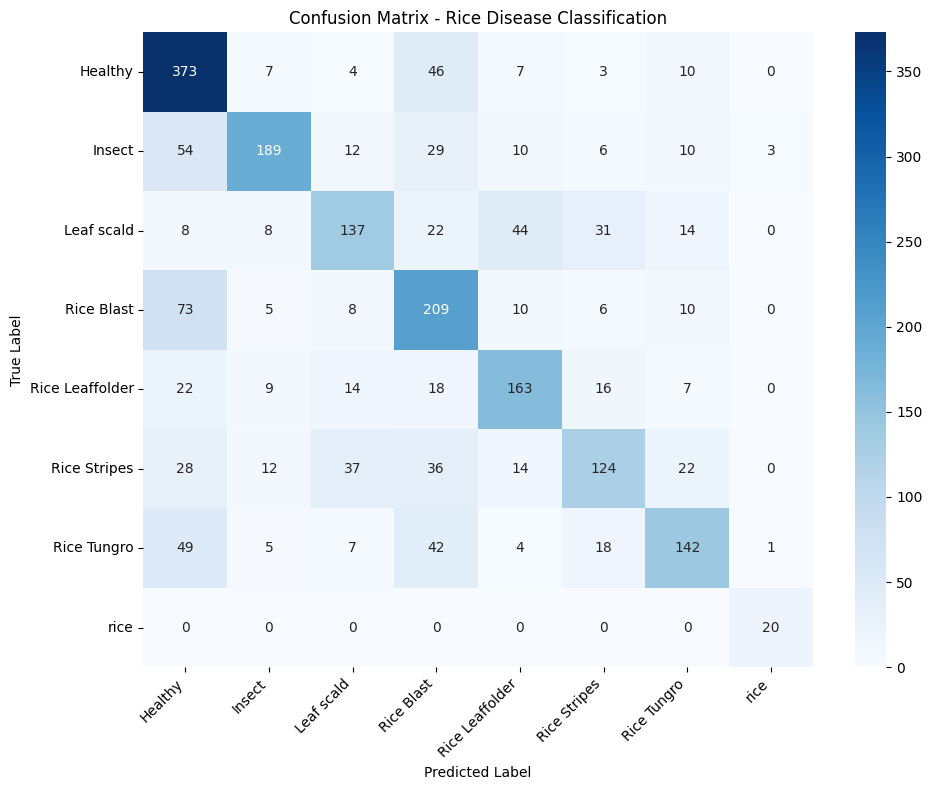

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Rice Disease Classification')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

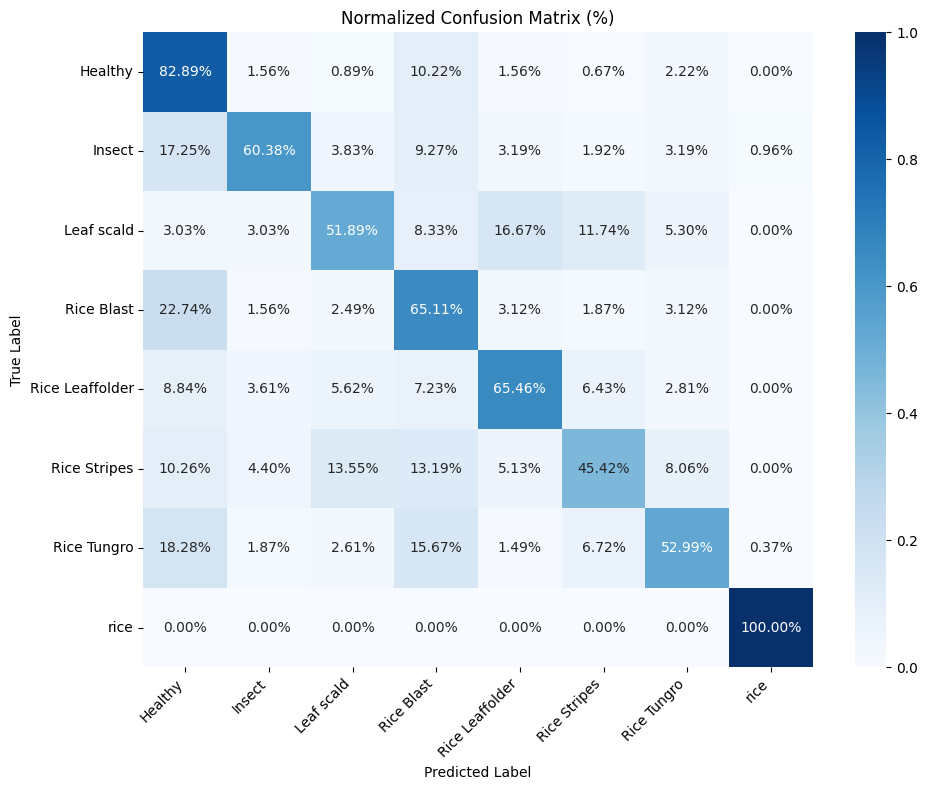

In [ ]:
import numpy as np

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_normalized.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open('/content/classification_report.txt', 'w') as f:
    f.write(report)

                 precision    recall  f1-score   support

        Healthy     0.6145    0.8289    0.7058       450
         Insect     0.8043    0.6038    0.6898       313
     Leaf scald     0.6256    0.5189    0.5673       264
     Rice Blast     0.5199    0.6511    0.5781       321
Rice Leaffolder     0.6468    0.6546    0.6507       249
   Rice Stripes     0.6078    0.4542    0.5199       273
    Rice Tungro     0.6605    0.5299    0.5880       268
           rice     0.8333    1.0000    0.9091        20

       accuracy                         0.6288      2158
      macro avg     0.6641    0.6552    0.6511      2158
   weighted avg     0.6399    0.6288    0.6249      2158



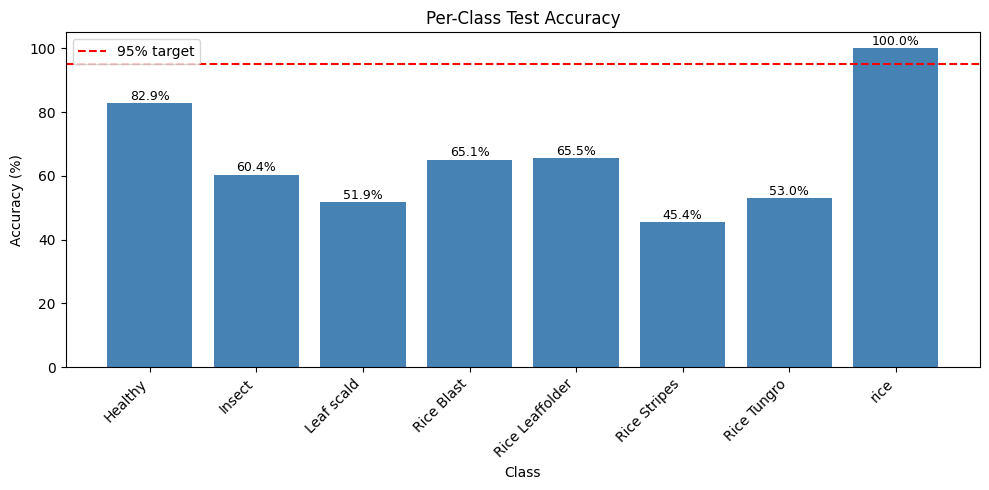

In [ ]:
class_accuracies = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, class_accuracies * 100, color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', label='95% target')
plt.xlabel('Class')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.ylim(0, 105)

for bar, acc_val in zip(bars, class_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{acc_val*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150)
plt.show()

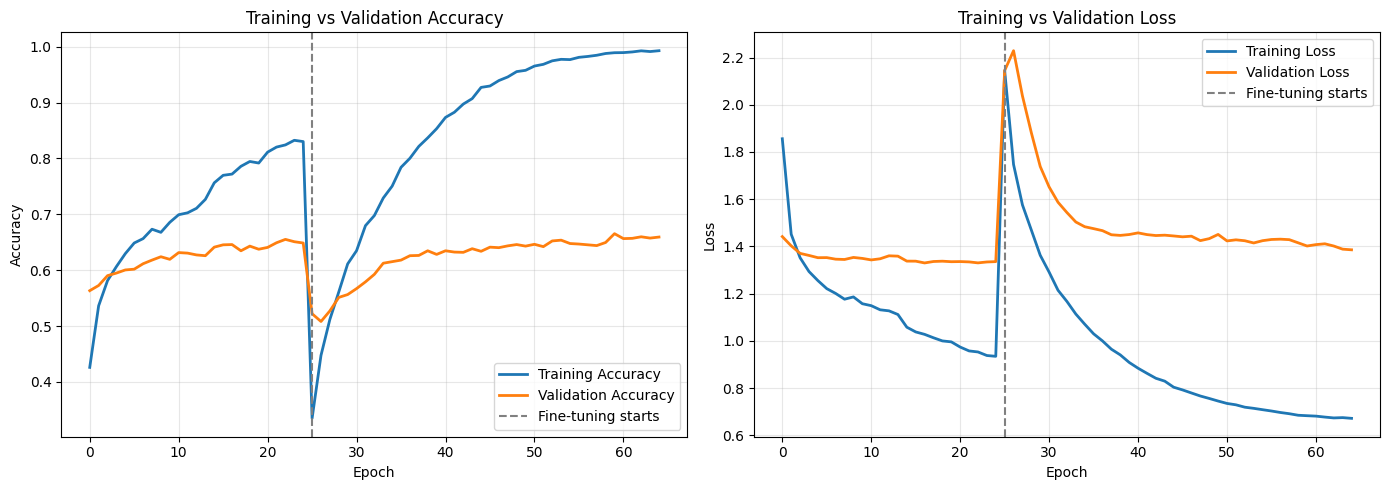

In [ ]:
def combine_histories(*histories):
    combined = {}
    for h in histories:
        for key, values in h.history.items():
            combined.setdefault(key, []).extend(values)
    return combined

all_history = combine_histories(history1, history2)  # add history3 if used

acc = all_history['accuracy']
val_acc = all_history['val_accuracy']
loss = all_history['loss']
val_loss = all_history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.axvline(x=len(history1.history['accuracy']), color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=len(history1.history['loss']), color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [ ]:
import os

drive_path = '/content/drive/MyDrive'
for f in os.listdir(drive_path):
    if f.endswith('.keras') or f.endswith('.h5'):
        print(f)

improved_rice_leaf_model.keras
improved_tomato_leaf_model.keras
best_phase1.keras
best_phase2.keras


In [ ]:
for f in os.listdir('/content'):
    if f.endswith('.keras') or f.endswith('.h5'):
        print(f)

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('/content/drive/MyDrive/best_phase2.keras')
print("Model loaded successfully")

Model loaded successfully


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('/content/rice_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite model saved, size:", len(tflite_model) / (1024*1024), "MB")

Saved artifact at '/tmp/tmpkpddm7wz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  133360401265872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401268368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401267984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401268560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401267792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401266064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401268176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360396059088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401266832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360401267600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1333603960588

In [ ]:
from google.colab import files
files.download('/content/rice_model.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()  # opens a file picker — choose your test image
image_path = list(uploaded.keys())[0]
print("Uploaded:", image_path)

Saving Augmented_0_9882.jpeg to Augmented_0_9882.jpeg
Uploaded: Augmented_0_9882.jpeg


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

IMG_SIZE = 224  # must match what you trained with

# Load and preprocess the image
img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

# Predict
predictions = model.predict(img_preprocessed)
predicted_index = np.argmax(predictions[0])
confidence = predictions[0][predicted_index] * 100

predicted_class = class_names[predicted_index]

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: Healthy
Confidence: 72.70%
